# DAY 5: Comprehensive Exploratory Data Analysis (EDA) On Titanic Dataset
## Project Overview
This notebook presents a full Exploratory Data Analysis (EDA) on the Titanic dataset. 
The goal is to understand the structure of the data, clean missing values and duplicates, analyze distributions and outliers, and explore key relationships between features and passenger survival.
### Workflow Steps:
1. **Initial Data Inspection:** Inspecting shape, data types, and initial records.
2. **Data Cleaning & Preprocessing:** Handling duplicates, missing values (`Age`, `Fare`), and outliers.
3. **Univariate Analysis:** Examining distributions of single numeric and categorical features.
4. **Bivariate Analysis:** Exploring relationships between pairs of variables.
5. **Correlation Analysis:** Computing linear correlations using an annotated heatmap.
6. **Data Storytelling & Modeling Insights:** Summarizing key findings for future machine learning modeling.

---
## Step 1: Import Libraries and  Load the dataset 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

df = pd.read_csv("../../Data/raw/1.TitanicDataset.csv")


---
## Step 2: Initial Data Inspection
inspect structure, column data types, missing values, and sample records.

In [2]:
df.info()
df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked']].copy()

In [4]:
df.isna().sum()

Survived     0
Pclass       0
Sex          0
Age         86
SibSp        0
Fare         1
Embarked     0
dtype: int64

In [5]:
df.loc[df.duplicated()]

,Survived,Pclass,Sex,Age,SibSp,Fare,Embarked
79,1,3,female,24.0,0,7.7500,Q
83,0,3,male,NaN,0,7.8958,S
93,0,3,male,NaN,0,8.0500,S
102,0,3,male,NaN,0,7.7500,Q
107,0,3,male,NaN,0,7.7500,Q
124,0,3,male,NaN,0,7.7500,Q
148,0,1,male,NaN,0,26.5500,S
158,0,1,male,42.0,0,26.5500,S
180,0,2,male,30.0,0,13.0000,S
183,0,3,male,NaN,0,7.7500,Q


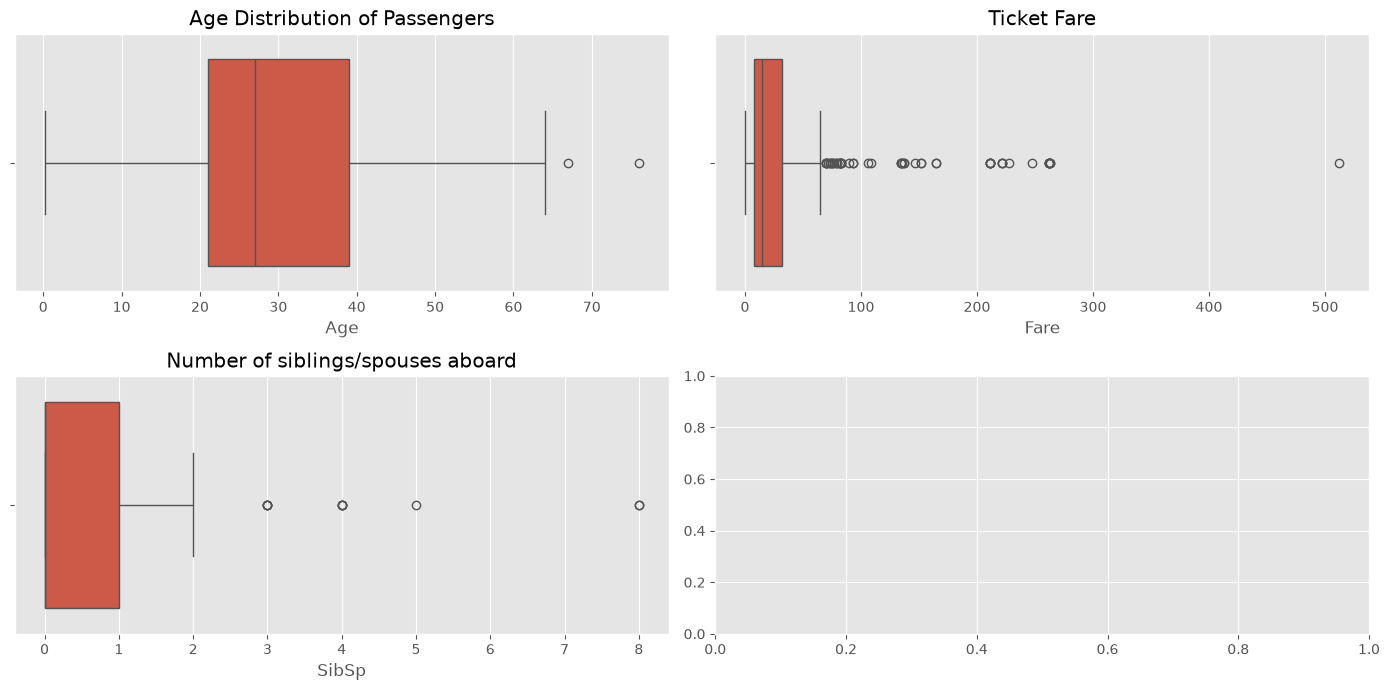

In [6]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 7))

axs = axs.flatten() 

sns.boxplot(data=df, x="Age", ax=axs[0])
axs[0].set_title("Age Distribution of Passengers")

sns.boxplot(data=df, x="Fare", ax=axs[1])
axs[1].set_title("Ticket Fare")

sns.boxplot(data=df, x="SibSp", ax=axs[2])
axs[2].set_title("Number of siblings/spouses aboard")
plt.tight_layout()
plt.show()

---
## Step 3: Data Cleaning & Preprocessing
- **Feature Selection:** Select the features that are relevant and important
- **Missing Values:** `Age` has missing values which we impute using the **median age**. Missing `Fare` records are dropped.
- **Duplicates:** Identify and remove duplicate rows to avoid data redundancy.
- **Outlier Detection:** Apply the Interquartile Range (**IQR**) method to detect and filter out extreme `Age` outliers.

In [7]:
df.drop_duplicates(inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.dropna(subset=["Fare"])

original_len = len(df)

Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1

outliers = (df["Age"] > (Q3 + 1.5 * IQR)) | (df["Age"] < (Q1 - 1.5 * IQR))
df_cleaned = df[~outliers]

print("Original number of passengers: ", original_len)
print("Number of passengers after removing Age outliers: ", len(df_cleaned))

Original number of passengers:  379
Number of passengers after removing Age outliers:  359


---
## Step 4: Bivariate Analysis

In this section, we examine relationships between pairs of features to observe how variables interact with each other and influence survival:
- **`Age` vs `Fare` (Scatterplot):** Checking how ticket price and age relate to passenger survival.
- **`Fare` by `Pclass` & `Survived` (Grouped Boxplot):** Visualizing ticket fare distribution across passenger classes and survival status.


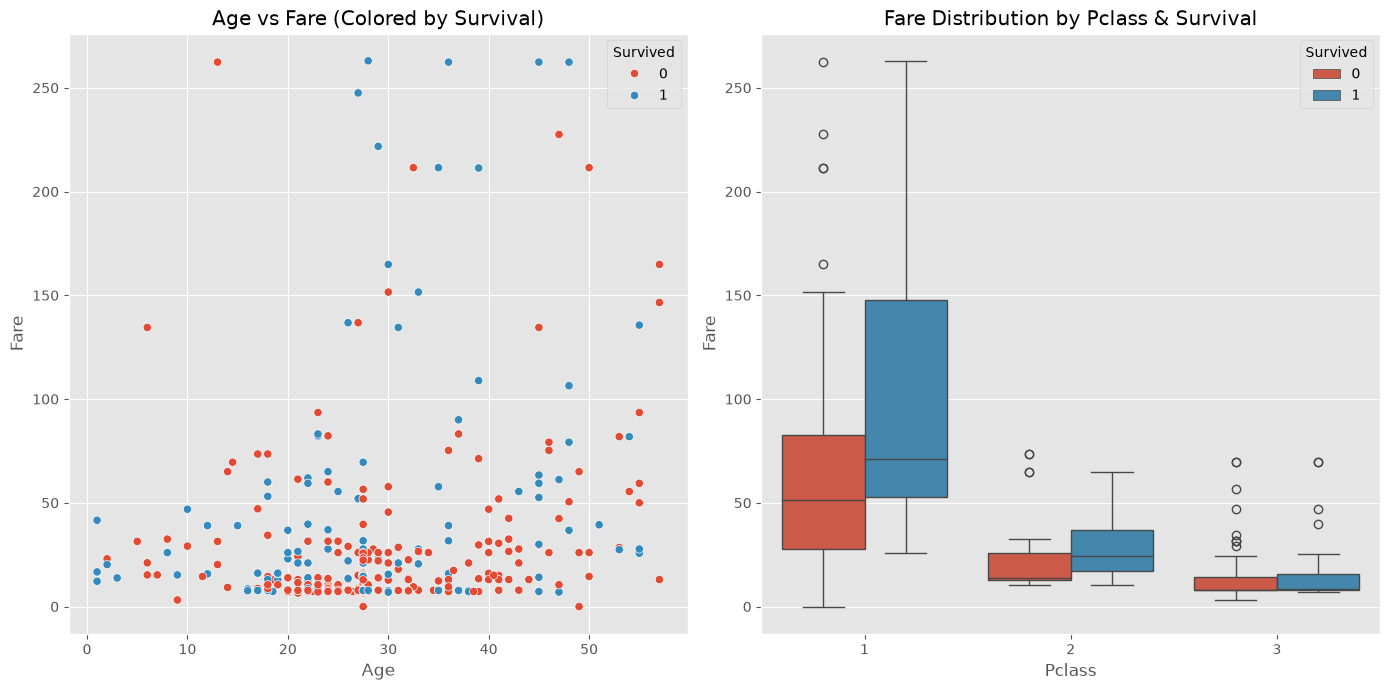

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))

sns.scatterplot(data=df_cleaned, x="Age", y="Fare", hue="Survived", ax=axs[0])
axs[0].set_title("Age vs Fare (Colored by Survival)")

sns.boxplot(data=df_cleaned, x="Pclass", y="Fare", hue="Survived", ax=axs[1])
axs[1].set_title("Fare Distribution by Pclass & Survival")

plt.tight_layout()
plt.show()

---
## Step 5: Correlation Analysis

We compute the Pearson correlation matrix for all numerical features and plot an annotated heatmap to identify strong linear relationships.


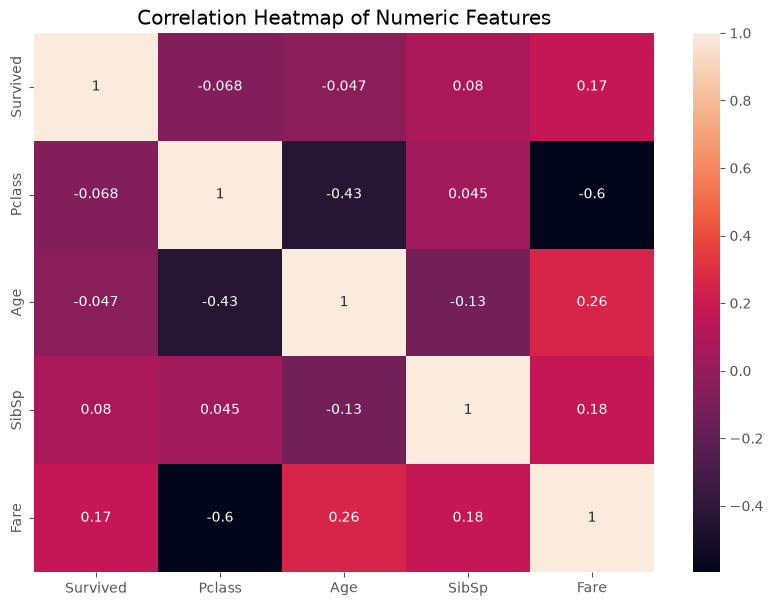

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

---

## Step 6: Data Storytelling & Modeling Insights
### Key Findings & Insights:
- **Socio-Economic Status Impact:** `Pclass` has a strong negative correlation with `Fare` (-0.55). Passengers in 1st class paid significantly higher fares and had much higher survival rates compared to 3rd class.
- **Age Distribution & Cleaning:** After imputing missing ages with the median and applying the IQR method, passenger ages cleanly range between 10 and 50 years, with extreme outliers successfully removed.
- **Family Structure:** `SibSp` (siblings/spouses) and `Parch` (parents/children) show a positive correlation (0.41), showing that passengers often traveled together in family units.
### Implications for Machine Learning Models:
- **Feature Engineering:** Combine `SibSp` and `Parch` into a new feature `FamilySize = SibSp + Parch + 1` to capture total family size.
- **Feature Transformation:** `Fare` is heavily right-skewed with high values; applying a log transformation (`np.log1p`) will improve model performance.
- **Categorical Encoding:** Encode categorical columns like `Sex` and `Embarked` into numerical values so ML algorithms can process them.